In [ ]:
# %pip install "https://github.com/gsbDBI/ds-wgan/archive/refs/heads/master.zip"

# Test the WGAN

In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import wgan

# Create the real training sample observed by the WGAN
rng = np.random.default_rng(42)
torch.manual_seed(42)

x = rng.normal(0, 1, 3000)
real = pd.DataFrame({
    "X": x,
    "Y": x + rng.normal(0, 1, 3000),
})

In [10]:
# Fit a WGAN to the joint distribution of X and Y
wrapper = wgan.DataWrapper(real, continuous_vars=["X", "Y"])
train_x, context = wrapper.preprocess(real)

specs = wgan.Specifications(
    wrapper,
    batch_size=256,
    max_epochs=1000,
    critic_steps=10,
    critic_d_hidden=[64, 64],
    generator_d_hidden=[64, 64],
    generator_dropout=0.0,
    test_set_size=300,
    print_every=250,
    device="cpu",
)

generator = wgan.Generator(specs)
critic = wgan.Critic(specs)
wgan.train(generator, critic, train_x, context, specs)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/wgan/wgan.py:66: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.stds  = [x.std(0,  keepdim=True) + 1e-5 for x in (continuous, context)]


settings: {'optimizer': <class 'torch.optim.adam.Adam'>, 'critic_d_hidden': [64, 64], 'critic_dropout': 0, 'critic_steps': 10, 'critic_lr': 0.0001, 'critic_gp_factor': 5, 'generator_d_hidden': [64, 64], 'generator_dropout': 0.0, 'generator_lr': 0.0001, 'generator_d_noise': 2, 'generator_optimizer': 'optimizer', 'max_epochs': 1000, 'batch_size': 256, 'test_set_size': 300, 'load_checkpoint': None, 'save_checkpoint': None, 'save_every': 100, 'print_every': 250, 'device': 'cpu'}
epoch 0 | step 12 | WD_test 0.04 | WD_train 0.05 | sec passed 0 |
epoch 250 | step 2762 | WD_test -0.04 | WD_train 0.0 | sec passed 3 |
epoch 500 | step 5512 | WD_test -0.0 | WD_train 0.12 | sec passed 3 |
epoch 750 | step 8262 | WD_test 0.02 | WD_train 0.06 | sec passed 3 |


            Theory  Real sample  WGAN sample
X std         1.00         1.01         0.97
Y std         1.41         1.41         1.38
corr(X,Y)     0.71         0.71         0.73
slope(Y~X)    1.00         0.99         1.04
std(Y-X)      1.00         1.00         0.94


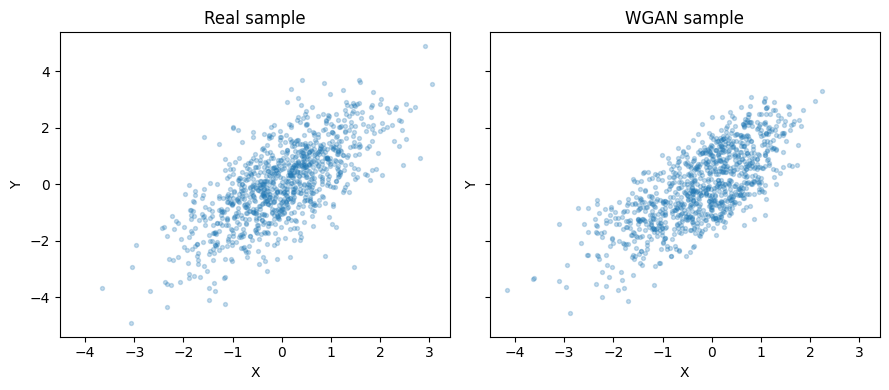

In [11]:

# Generate new observations
generator.eval()
with torch.no_grad():
    fake = wrapper.apply_generator(
        generator, pd.DataFrame(index=range(10000))
    )

# Compare the real and generated distributions
def summary(data):
    return pd.Series({
        "X std": data["X"].std(),
        "Y std": data["Y"].std(),
        "corr(X,Y)": data["X"].corr(data["Y"]),
        "slope(Y~X)": np.polyfit(data["X"], data["Y"], 1)[0],
        "std(Y-X)": (data["Y"] - data["X"]).std(),
    })

theory = pd.Series({
    "X std": 1,
    "Y std": np.sqrt(2),
    "corr(X,Y)": 1 / np.sqrt(2),
    "slope(Y~X)": 1,
    "std(Y-X)": 1,
})

print(pd.DataFrame({
    "Theory": theory,
    "Real sample": summary(real),
    "WGAN sample": summary(fake),
}).round(2))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)

for ax, (title, data) in zip(
    axes, [("Real sample", real), ("WGAN sample", fake)]
):
    sample = data.sample(1000, random_state=42)
    ax.scatter(sample["X"], sample["Y"], s=8, alpha=0.25)
    ax.set(title=title, xlabel="X", ylabel="Y")

plt.tight_layout()
plt.show()

# Test on the JTPA dataset

In [38]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import wgan

from pathlib import Path

data_path = next((path for path in [Path("jtpa_han.tab"), Path("JTPA/jtpa_han.tab")] if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(f"JTPA data file not found from {Path.cwd()}")
my_data = pd.read_csv(data_path, sep="\t")
my_data = my_data.drop(columns=["recid", "n_hs2_abv"])

my_data["edu"] = (
    my_data["edu"].ge(12)
    .where(my_data["edu"].notna())
    .astype("Int64")
)

log_prevearn = np.log1p(my_data["prevearn"])
my_data["prevearn"] = (
    (log_prevearn - log_prevearn.mean())
    / log_prevearn.std(ddof=1)
)

my_data["n_hs2"] = (
    my_data["n_hs2"].ge(13)
    .where(my_data["n_hs2"].notna())
    .astype("Int64")
)

earnings_median = my_data["earnings"].median(skipna=False)
my_data["earnings"] = (
    my_data["earnings"].gt(earnings_median)
    .where(my_data["earnings"].notna() & pd.notna(earnings_median))
    .astype("Int64")
)

my_data.columns = ["A1", "Z1", "Y2", "L1", "A0", "Z0", "L0"]
print(my_data.head())
# my_data.to_csv("JTPA/jpta_han.csv", index=False)

   A1  Z1  Y2        L1  A0  Z0  L0
0   1   1   0 -1.524100   1   1   0
1   1   1   0  0.697583   0   1   0
2   0   1   1 -1.524100   1   1   0
3   0   1   1  0.960869   0   1   0
4   0   0   1  0.964397   0   0   0


In [39]:
# Encode the point mass in L1 before fitting the joint distribution
binary_vars = ["A1", "Z1", "Y2", "A0", "Z0", "L0"]
model_data = my_data.copy()
if model_data.isna().any().any():
    raise ValueError("WGAN training does not accept missing values.")

for column in binary_vars:
    model_data[column] = model_data[column].astype("int64")
    if not model_data[column].isin([0, 1]).all():
        raise ValueError(f"{column} must contain only 0 and 1.")

l1_lower_bound = float(model_data["L1"].min())
training_data = model_data.drop(columns=["L1"]).copy()
training_data["L1_floor"] = model_data["L1"].eq(l1_lower_bound).astype("int64")
training_data["L1_above"] = (model_data["L1"] - l1_lower_bound).where(
    training_data["L1_floor"].eq(0), 0.0
)
context_vars = ["A1", "Z1", "L1_floor"]
training_binary_vars = [column for column in binary_vars if column not in context_vars]

import random
training_seed = 42
random.seed(training_seed)
np.random.seed(training_seed)
torch.manual_seed(training_seed)
torch.use_deterministic_algorithms(True)

jtpa_wrapper = wgan.DataWrapper(
    training_data,
    continuous_vars=["L1_above"],
    categorical_vars=training_binary_vars,
    context_vars=context_vars,
    continuous_lower_bounds={"L1_above": 0.0},
)
jtpa_x, jtpa_context = jtpa_wrapper.preprocess(training_data)

jtpa_specs = wgan.Specifications(
    jtpa_wrapper,
    batch_size=256,
    max_epochs=600,
    critic_steps=5,
    critic_d_hidden=[16],
    generator_d_hidden=[16],
    generator_dropout=0,
    test_set_size=int(0.1 * len(model_data)),
    print_every=100,
    device="cpu",
)
jtpa_generator = wgan.Generator(jtpa_specs)
jtpa_critic = wgan.Critic(jtpa_specs)
wgan.train(jtpa_generator, jtpa_critic, jtpa_x, jtpa_context, jtpa_specs)

settings: {'optimizer': <class 'torch.optim.adam.Adam'>, 'critic_d_hidden': [16], 'critic_dropout': 0, 'critic_steps': 5, 'critic_lr': 0.0001, 'critic_gp_factor': 5, 'generator_d_hidden': [16], 'generator_dropout': 0, 'generator_lr': 0.0001, 'generator_d_noise': 9, 'generator_optimizer': 'optimizer', 'max_epochs': 600, 'batch_size': 256, 'test_set_size': 922, 'load_checkpoint': None, 'save_checkpoint': None, 'save_every': 100, 'print_every': 100, 'device': 'cpu'}
epoch 0 | step 34 | WD_test -0.01 | WD_train -0.01 | sec passed 0 |
epoch 100 | step 3334 | WD_test 0.75 | WD_train 0.74 | sec passed 3 |
epoch 200 | step 6634 | WD_test 0.9 | WD_train 0.92 | sec passed 3 |
epoch 300 | step 9934 | WD_test 0.87 | WD_train 0.88 | sec passed 3 |
epoch 400 | step 13234 | WD_test 0.68 | WD_train 0.7 | sec passed 3 |
epoch 500 | step 16534 | WD_test 0.56 | WD_train 0.56 | sec passed 3 |


In [42]:
# Draw and save 50,000 reproducible synthetic observations
generation_seed = 2025
random.seed(generation_seed)
np.random.seed(generation_seed)
torch.manual_seed(generation_seed)
n_generated = 50000
context_data = training_data[context_vars].sample(
    n=n_generated, replace=True, random_state=generation_seed
).reset_index(drop=True)
jtpa_generator.eval()
with torch.no_grad():
    generated_augmented = jtpa_wrapper.apply_generator(
        jtpa_generator, context_data
    )

generated_data = generated_augmented[binary_vars].copy()
generated_data[binary_vars] = generated_data[binary_vars].astype("int64")
generated_data["L1"] = np.where(
    generated_augmented["L1_floor"].eq(1),
    l1_lower_bound,
    l1_lower_bound + generated_augmented["L1_above"],
)
generated_data = generated_data[model_data.columns]
assert generated_data[binary_vars].isin([0, 1]).all().all()
assert len(generated_data) == n_generated
generated_path = data_path.parent / "jtpa_wgan.csv"
generated_data.to_csv(generated_path, index=False)
print(f"Saved {len(generated_data):,} rows to {generated_path.resolve()}")
print(generated_data.head())

Saved 50,000 rows to /Users/main/Coding/LIV_MSM-main/JTPA/jtpa_wgan.csv
   A1  Z1  Y2        L1  A0  Z0  L0
0   0   1   0  0.636159   1   1   0
1   1   1   0 -1.524100   1   0   0
2   0   0   0 -1.524100   0   0   0
3   1   1   0  0.910424   0   1   0
4   1   1   1 -1.524100   1   1   1


Sample sizes: real=9,223, WGAN=50,000
Share equal to 1
     Real   WGAN
A1  0.440  0.439
Z1  0.665  0.666
Y2  0.500  0.499
A0  0.627  0.615
Z0  0.732  0.755
L0  0.465  0.448

L1 distribution
                      Real   WGAN
L1 mean               0.00 -0.010
L1 std                1.00  0.986
L1 lower-bound share  0.28  0.285

A1 and Z1 joint shares
Real
Z1      0      1
A1              
0   0.330  0.230
1   0.005  0.435
WGAN
Z1      0      1
A1              
0   0.329  0.232
1   0.005  0.435

A1 and Z1 group counts (different sample sizes)
       Real   WGAN
A1 Z1             
0  0   3047  16460
   1   2118  11575
1  0     43    228
   1   4015  21737

Y2 rate by A1 and Z1
        Real   WGAN
A1 Z1              
0  0   0.486  0.480
   1   0.430  0.462
1  0   0.442  0.583
   1   0.548  0.532

Mean absolute pairwise correlation difference: 0.065


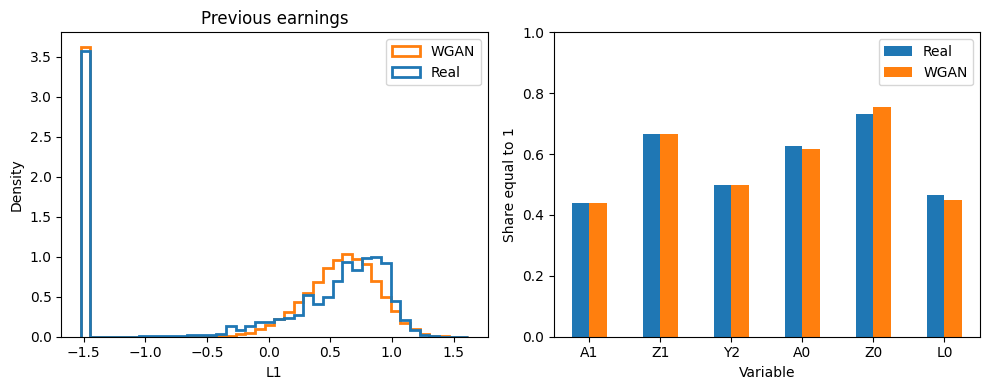

In [43]:
# Compare marginals, the lower-bound mass, and key joint relationships
print(f"Sample sizes: real={len(model_data):,}, WGAN={len(generated_data):,}")
binary_summary = pd.DataFrame({
    "Real": model_data[binary_vars].mean(),
    "WGAN": generated_data[binary_vars].mean(),
})
print("Share equal to 1")
print(binary_summary.round(3))

l1_lower_bound = model_data["L1"].min()
l1_summary = pd.DataFrame({
    "Real": [
        model_data["L1"].mean(),
        model_data["L1"].std(),
        np.isclose(model_data["L1"], l1_lower_bound).mean(),
    ],
    "WGAN": [
        generated_data["L1"].mean(),
        generated_data["L1"].std(),
        np.isclose(generated_data["L1"], l1_lower_bound, atol=1e-5).mean(),
    ],
}, index=["L1 mean", "L1 std", "L1 lower-bound share"])
print("\nL1 distribution")
print(l1_summary.round(3))

print("\nA1 and Z1 joint shares")
for label, data in [("Real", model_data), ("WGAN", generated_data)]:
    print(label)
    print(pd.crosstab(data["A1"], data["Z1"], normalize="all").round(3))

print("\nA1 and Z1 group counts (different sample sizes)")
print(pd.DataFrame({
    "Real": model_data.groupby(["A1", "Z1"]).size(),
    "WGAN": generated_data.groupby(["A1", "Z1"]).size(),
}).fillna(0).astype(int))

print("\nY2 rate by A1 and Z1")
print(pd.concat({
    "Real": model_data.groupby(["A1", "Z1"])["Y2"].mean(),
    "WGAN": generated_data.groupby(["A1", "Z1"])["Y2"].mean(),
}, axis=1).round(3))

corr_diff = (model_data.corr() - generated_data.corr()).abs().to_numpy()
upper = np.triu_indices_from(corr_diff, k=1)
print("\nMean absolute pairwise correlation difference:", round(corr_diff[upper].mean(), 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(
    [model_data["L1"], generated_data["L1"]],
    bins=40, density=True, histtype="step", linewidth=2,
    label=["Real", "WGAN"],
)
axes[0].set(xlabel="L1", ylabel="Density", title="Previous earnings")
axes[0].legend()

binary_summary.plot.bar(ax=axes[1], rot=0)
axes[1].set(xlabel="Variable", ylabel="Share equal to 1", ylim=(0, 1))
plt.tight_layout()
plt.show()

The generated sample approximates the observed joint distribution. The A1, Z1, and L1_floor combinations are resampled from the observed data to preserve their empirical shares, including the rare A1=1, Z1=0 group. Compare group shares rather than raw counts because the sample sizes differ. Only 43 real observations have A1=1, Z1=0, so the Y2 rate in that group remains uncertain. The 50,000 generated rows are not 50,000 new independent observations and do not reveal counterfactual outcomes.